In [1]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import particle
from particle import Particle
import seaborn as sns

from funcs import Neutrinos_dk2nu
data = Neutrinos_dk2nu("./DATA/NuBeam_production_BooNE_50m_I174000A_0.dk2nu.root")

Expected Total KDARs: 171.79932488462015


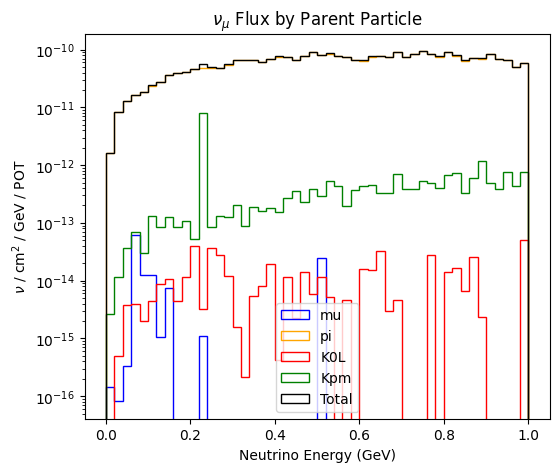

In [13]:

bins = np.linspace(0,1,51)
fig, ax1 = plt.subplots(figsize=(6, 5))

for label, (p_pdgs, colour) in data.parent_groups.items():
    mask = data.flavour_mask(14) & data.parent_mask(p_pdgs)
    ax1.hist(data.energies[mask], bins=bins, weights=data.tot_wgts[mask],
            label=label, color=colour, histtype="step", linewidth=1)

# Total Flux
ax1.hist(data.energies[data.flavour_mask(14)], bins=bins, weights=data.tot_wgts[data.flavour_mask(14)], label="Total", 
        color="black", histtype="step", linewidth=1)

ax1.set_xlabel("Neutrino Energy (GeV)")
ax1.set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
ax1.set_title(r"$\nu_\mu$ Flux by Parent Particle")
ax1.legend()
ax1.set_yscale("log")
#ax.set_xlim(0,1)
print(f"Expected Total KDARs: {data.event_count([0.235, 0.236], 14, [321, -321, 130])}")


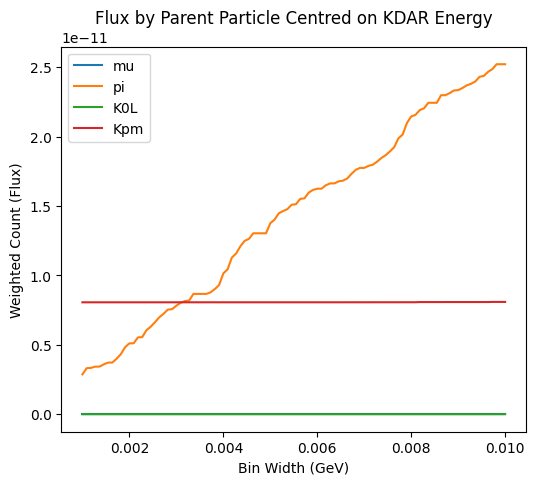

In [3]:

bin_widths = np.linspace(0.001, 0.01, 100)
parent_counts = {
    "mu" : [],
    "pi" : [],
    "K0L" : [],
    "Kpm" : []
}

for i in range(100):
    for label, (p_pdgs, colour) in data.parent_groups.items():
        kdar_energy = data.energy_mask([(0.2355 - bin_widths[i]/2), (0.2355 + bin_widths[i]/2)])
        mask = data.parent_mask(p_pdgs) & kdar_energy & data.flavour_mask(14)
        parent_counts[label].append(np.sum(data.tot_wgts[mask]))

fig, ax = plt.subplots(figsize=(6,5))

for label, (counts) in parent_counts.items():
    ax.plot(bin_widths, counts, label=label)

ax.set_ylabel("Weighted Count (Flux)")
ax.set_xlabel("Bin Width (GeV)")
ax.set_title("Flux by Parent Particle Centred on KDAR Energy")
ax.legend()





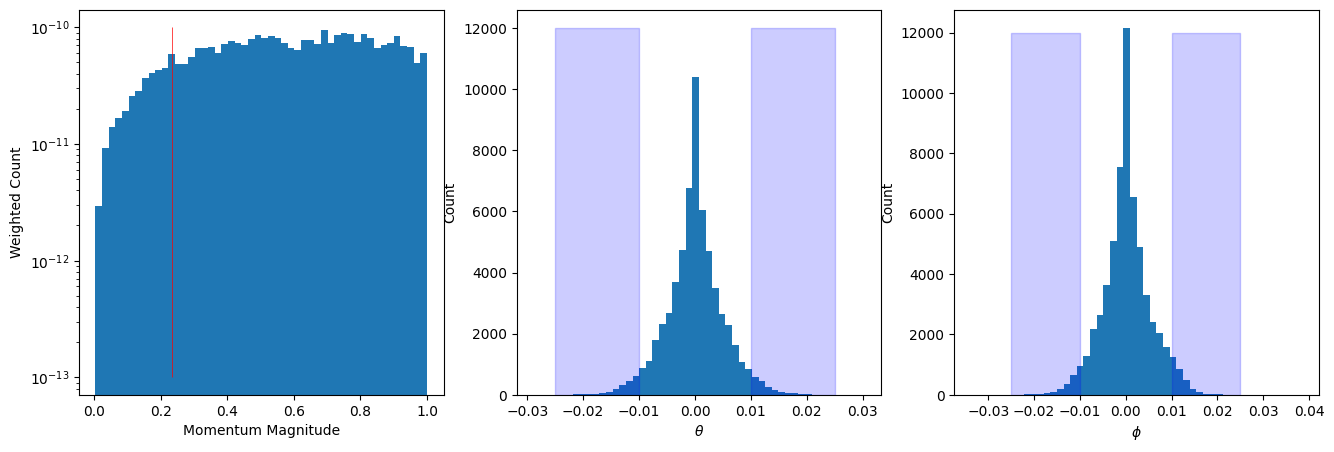

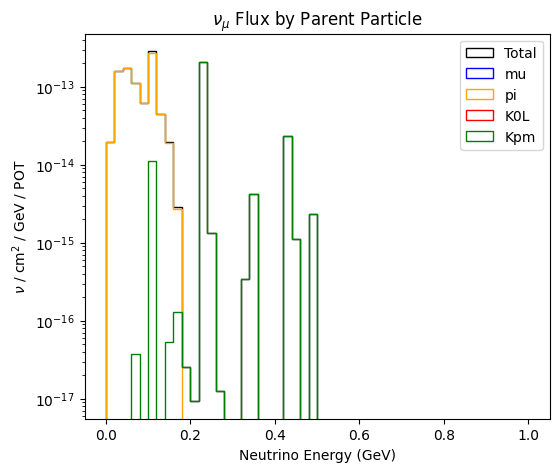

In [7]:


thetas  = np.arctan((data.py/data.pz))
phis    = np.arctan((data.px/data.pz))
magnitudes = np.sqrt(data.px**2 + data.py**2 + data.pz**2) 

fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(16, 5))

mask = (data.flavour_mask(14) & data.energy_mask())
vals, edges, _ = ax1.hist(magnitudes[mask], bins=50, weights=data.tot_wgts[mask])
ax1.vlines([0.2355], 1e-13, 1e-10, linewidths=[0.5], colors=["red"])
ax1.set_yscale("log")
ax2.hist(phis, bins=50)
ax3.hist(thetas, bins=50)

angle_mag = 0.01
theta_mask = (thetas >= angle_mag) | (thetas <= -angle_mag)
phi_mask   = (phis >= angle_mag) | (phis <= -angle_mag)

ax2.fill_between([-0.025, -angle_mag], 0, 12000, color="blue", alpha=0.2)
ax2.fill_between([+0.025, +angle_mag], 0, 12000, color="blue", alpha=0.2)
ax3.fill_between([-0.025, -angle_mag], 0, 12000, color="blue", alpha=0.2)
ax3.fill_between([+0.025, +angle_mag], 0, 12000, color="blue", alpha=0.2)

ax1.set_ylabel("Weighted Count")
ax1.set_xlabel("Momentum Magnitude")
ax2.set_ylabel("Count")
ax2.set_xlabel(r"$\theta$")
ax3.set_ylabel("Count")
ax3.set_xlabel(r"$\phi$")


plt.show()

fig, ax = plt.subplots(figsize=(6,5))

# Total Flux
mask = (theta_mask & data.flavour_mask(14) & data.energy_mask() & phi_mask)
ax.hist(data.energies[mask], bins=bins, weights=data.tot_wgts[mask], label="Total", 
        color="black", histtype="step", linewidth=1)

for label, (p_pdgs, colour) in data.parent_groups.items():
    mask = data.parent_mask(p_pdgs) & theta_mask & data.flavour_mask(14) & data.energy_mask() & phi_mask
    ax.hist(data.energies[mask], bins=bins, weights=data.tot_wgts[mask],
            label=label, color=colour, histtype="step", linewidth=1)



ax.set_xlabel("Neutrino Energy (GeV)")
ax.set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
ax.set_title(r"$\nu_\mu$ Flux by Parent Particle")
ax.legend()
ax.set_yscale("log")

plt.show()

Expected KDARs: 65.64395241686702


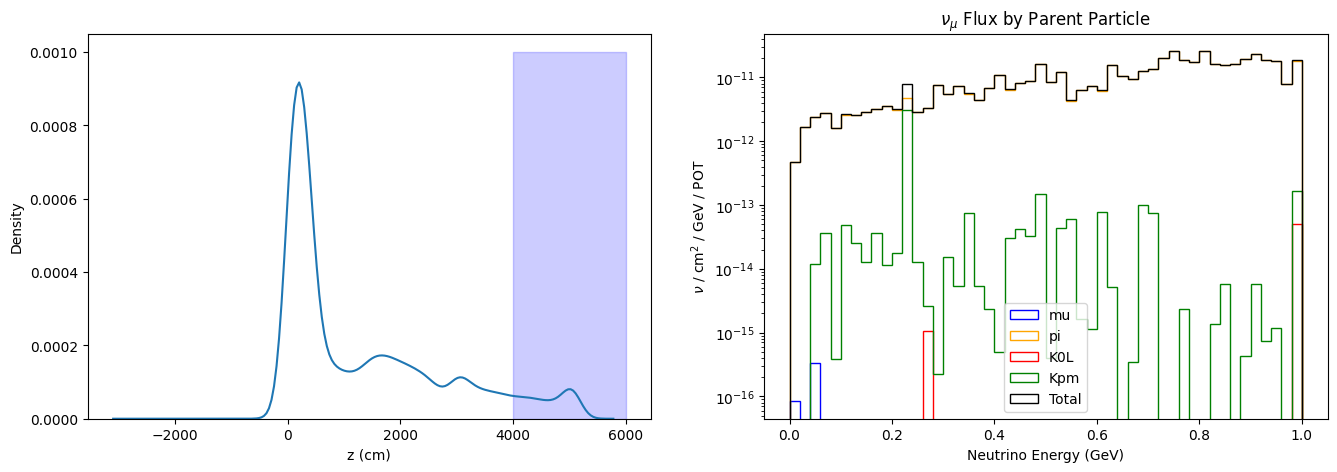

In [10]:
# Parent Decay Positions

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,5))
sns.kdeplot(data.decay_z, ax=ax1)
ax1.set_xlabel("z (cm)")

decay_mask = (data.decay_z > 4000)
ax1.fill_between([4000, 6000], 0, 0.001, color="blue", alpha=0.2)



for label, (p_pdgs, colour) in data.parent_groups.items():
    mask = data.flavour_mask(14) & data.parent_mask(p_pdgs) & decay_mask
    ax2.hist(data.energies[mask], bins=bins, weights=data.tot_wgts[mask],
            label=label, color=colour, histtype="step", linewidth=1)

# Total Flux
ax2.hist(data.energies[data.flavour_mask(14) & decay_mask], bins=bins, weights=data.tot_wgts[data.flavour_mask(14) & decay_mask], label="Total", 
        color="black", histtype="step", linewidth=1)

ax2.set_xlabel("Neutrino Energy (GeV)")
ax2.set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
ax2.set_title(r"$\nu_\mu$ Flux by Parent Particle")
ax2.legend()
ax2.set_yscale("log")
#ax.set_xlim(0,1)

print(f"Expected KDARs: {data.event_count([0.235, 0.236], 14, [321, -321, 130], decay_mask)}")
